# Evaluation Unimodal — EfficientNet B0/B1/B2
Evaluation of all 12 unimodal experiments on the fixed test set.
Metrics: Accuracy, Recall, F1, AUC — global and per class.

In [1]:
import os
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

import torch
from config import (
    METRICS_DIR, FIGURES_DIR, MODELS_DIR,
    CLASSES, CLASS_NAMES_FULL, IDX_TO_CLASS, NUM_CLASSES
)
from evaluate import evaluate_model

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print('Imports OK')

/home/maialen/pfg-venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
Imports OK


/home/maialen/pfg-venv/lib/python3.8/site-packages/albumentations/__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


## 1. Evaluate All Experiments on Test Set
For each experiment, load the best fold model (highest AUC) and evaluate on the fixed test set.

In [2]:
# Load kfold summaries to find best fold per experiment
experiments = [
    ('b0', 'none'),
    ('b0', 'dullrazor'),
    ('b0', 'colorconstancy'),
    ('b0', 'both'),
    ('b1', 'none'),
    ('b1', 'dullrazor'),
    ('b1', 'colorconstancy'),
    ('b1', 'both'),
    ('b2', 'none'),
    ('b2', 'dullrazor'),
    ('b2', 'colorconstancy'),
    ('b2', 'both'),
    ('b3', 'none'),
    ('b3', 'dullrazor'),
    ('b3', 'colorconstancy'),
    ('b3', 'both'),
]

def get_best_fold_model(version, preprocessing):
    """Return the path of the best fold model based on K-Fold AUC."""
    import json
    record_path = os.path.join(
        METRICS_DIR, f'efficientnet_{version}_{preprocessing}_record.json'
    )
    with open(record_path, 'r') as f:
        record = json.load(f)

    fold_aucs  = record['results']['fold_aucs']
    # fold_aucs is a string like "[0.96, 0.95, ...]"
    if isinstance(fold_aucs, str):
        import ast
        fold_aucs = ast.literal_eval(fold_aucs)

    best_fold  = int(np.argmax(fold_aucs))
    model_path = os.path.join(
        MODELS_DIR,
        f'efficientnet_{version}_{preprocessing}_fold{best_fold}.pth'
    )
    print(f'efficientnet_{version}_{preprocessing} → best fold: {best_fold} (AUC: {fold_aucs[best_fold]:.4f})')
    return model_path

print('Best fold per experiment:')
for version, preprocessing in experiments:
    get_best_fold_model(version, preprocessing)

Best fold per experiment:
efficientnet_b0_none → best fold: 2 (AUC: 0.9623)
efficientnet_b0_dullrazor → best fold: 2 (AUC: 0.9614)
efficientnet_b0_colorconstancy → best fold: 2 (AUC: 0.9624)
efficientnet_b0_both → best fold: 2 (AUC: 0.9582)
efficientnet_b1_none → best fold: 2 (AUC: 0.9606)
efficientnet_b1_dullrazor → best fold: 2 (AUC: 0.9538)
efficientnet_b1_colorconstancy → best fold: 4 (AUC: 0.9534)
efficientnet_b1_both → best fold: 2 (AUC: 0.9466)
efficientnet_b2_none → best fold: 2 (AUC: 0.9623)
efficientnet_b2_dullrazor → best fold: 0 (AUC: 0.9535)
efficientnet_b2_colorconstancy → best fold: 4 (AUC: 0.9604)
efficientnet_b2_both → best fold: 2 (AUC: 0.9479)
efficientnet_b3_none → best fold: 2 (AUC: 0.9636)
efficientnet_b3_dullrazor → best fold: 2 (AUC: 0.9588)
efficientnet_b3_colorconstancy → best fold: 0 (AUC: 0.9604)
efficientnet_b3_both → best fold: 2 (AUC: 0.9536)


## 2. Run Evaluation on Test Set
This may take a few minutes per experiment.

In [3]:
all_metrics = []

for version, preprocessing in experiments:
    model_path = get_best_fold_model(version, preprocessing)
    metrics    = evaluate_model(
        model_path           = model_path,
        preprocessing_mode   = preprocessing,
        efficientnet_version = version,
        device               = device,
    )
    all_metrics.append(metrics)

print('\nAll experiments evaluated.')

efficientnet_b0_none → best fold: 2 (AUC: 0.9623)

Evaluating: efficientnet_b0_none


/home/maialen/skin_lesion_PFG/notebooks/../src/evaluate.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devic


──────────────────────────────────────────────────
  Accuracy:      0.8163
  Recall macro:  0.7184
  F1 macro:      0.6999
  AUC macro:     0.9552
──────────────────────────────────────────────────

Per-class metrics:
  Actinic Keratosis         Recall: 0.5882 | F1: 0.5769
  Basal Cell Carcinoma      Recall: 0.8312 | F1: 0.7529
  Benign Keratosis          Recall: 0.6624 | F1: 0.6520
  Dermatofibroma            Recall: 0.6818 | F1: 0.6667
  Melanoma                  Recall: 0.7619 | F1: 0.6481
  Melanocytic Nevi          Recall: 0.8670 | F1: 0.9027
  Vascular Lesion           Recall: 0.6364 | F1: 0.7000

                      precision    recall  f1-score   support

   Actinic Keratosis       0.57      0.59      0.58        51
Basal Cell Carcinoma       0.69      0.83      0.75        77
    Benign Keratosis       0.64      0.66      0.65       157
      Dermatofibroma       0.65      0.68      0.67        22
            Melanoma       0.56      0.76      0.65       168
    Melanocytic

/home/maialen/skin_lesion_PFG/notebooks/../src/evaluate.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devic


──────────────────────────────────────────────────
  Accuracy:      0.7989
  Recall macro:  0.7068
  F1 macro:      0.6835
  AUC macro:     0.9446
──────────────────────────────────────────────────

Per-class metrics:
  Actinic Keratosis         Recall: 0.7451 | F1: 0.6786
  Basal Cell Carcinoma      Recall: 0.8182 | F1: 0.7636
  Benign Keratosis          Recall: 0.6688 | F1: 0.6325
  Dermatofibroma            Recall: 0.5000 | F1: 0.5500
  Melanoma                  Recall: 0.7381 | F1: 0.6049
  Melanocytic Nevi          Recall: 0.8410 | F1: 0.8885
  Vascular Lesion           Recall: 0.6364 | F1: 0.6667

                      precision    recall  f1-score   support

   Actinic Keratosis       0.62      0.75      0.68        51
Basal Cell Carcinoma       0.72      0.82      0.76        77
    Benign Keratosis       0.60      0.67      0.63       157
      Dermatofibroma       0.61      0.50      0.55        22
            Melanoma       0.51      0.74      0.60       168
    Melanocytic

...


──────────────────────────────────────────────────
  Accuracy:      0.7816
  Recall macro:  0.7086
  F1 macro:      0.6716
  AUC macro:     0.9608
──────────────────────────────────────────────────

Per-class metrics:
  Actinic Keratosis         Recall: 0.5882 | F1: 0.6316
  Basal Cell Carcinoma      Recall: 0.7662 | F1: 0.7421
  Benign Keratosis          Recall: 0.7134 | F1: 0.6569
  Dermatofibroma            Recall: 0.6364 | F1: 0.6087
  Melanoma                  Recall: 0.7619 | F1: 0.5766
  Melanocytic Nevi          Recall: 0.8120 | F1: 0.8731
  Vascular Lesion           Recall: 0.6818 | F1: 0.6122

                      precision    recall  f1-score   support

   Actinic Keratosis       0.68      0.59      0.63        51
Basal Cell Carcinoma       0.72      0.77      0.74        77
    Benign Keratosis       0.61      0.71      0.66       157
      Dermatofibroma       0.58      0.64      0.61        22
            Melanoma       0.46      0.76      0.58       168
    Melanocytic

/home/maialen/skin_lesion_PFG/notebooks/../src/evaluate.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devic


──────────────────────────────────────────────────
  Accuracy:      0.7882
  Recall macro:  0.6933
  F1 macro:      0.6679
  AUC macro:     0.9537
──────────────────────────────────────────────────

Per-class metrics:
  Actinic Keratosis         Recall: 0.5294 | F1: 0.5400
  Basal Cell Carcinoma      Recall: 0.7273 | F1: 0.7089
  Benign Keratosis          Recall: 0.7134 | F1: 0.6154
  Dermatofibroma            Recall: 0.6364 | F1: 0.5385
  Melanoma                  Recall: 0.6250 | F1: 0.5753
  Melanocytic Nevi          Recall: 0.8490 | F1: 0.8876
  Vascular Lesion           Recall: 0.7727 | F1: 0.8095

                      precision    recall  f1-score   support

   Actinic Keratosis       0.55      0.53      0.54        51
Basal Cell Carcinoma       0.69      0.73      0.71        77
    Benign Keratosis       0.54      0.71      0.62       157
      Dermatofibroma       0.47      0.64      0.54        22
            Melanoma       0.53      0.62      0.58       168
    Melanocytic

/home/maialen/skin_lesion_PFG/notebooks/../src/evaluate.py:142: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=devic


──────────────────────────────────────────────────
  Accuracy:      0.7268
  Recall macro:  0.6496
  F1 macro:      0.6088
  AUC macro:     0.9446
──────────────────────────────────────────────────

Per-class metrics:
  Actinic Keratosis         Recall: 0.6667 | F1: 0.5667
  Basal Cell Carcinoma      Recall: 0.7143 | F1: 0.6433
  Benign Keratosis          Recall: 0.6178 | F1: 0.5640
  Dermatofibroma            Recall: 0.4091 | F1: 0.4286
  Melanoma                  Recall: 0.7500 | F1: 0.5175
  Melanocytic Nevi          Recall: 0.7530 | F1: 0.8413
  Vascular Lesion           Recall: 0.6364 | F1: 0.7000

                      precision    recall  f1-score   support

   Actinic Keratosis       0.49      0.67      0.57        51
Basal Cell Carcinoma       0.59      0.71      0.64        77
    Benign Keratosis       0.52      0.62      0.56       157
      Dermatofibroma       0.45      0.41      0.43        22
            Melanoma       0.39      0.75      0.52       168
    Melanocytic

## 3. Results Comparison — All Metrics

In [4]:
# Load all test metrics
metric_files = glob(os.path.join(METRICS_DIR, '*_test_metrics.csv'))
test_results = []
for f in metric_files:
    df_m = pd.read_csv(f)
    test_results.append(df_m)

test_df = pd.concat(test_results, ignore_index=True)

# Order by backbone and preprocessing
preprocess_order = {'none': 0, 'dullrazor': 1, 'colorconstancy': 2, 'both': 3}
backbone_order   = {'b0': 0, 'b1': 1, 'b2': 2, 'b3': 3}
test_df['_b_order'] = test_df['model'].map(backbone_order)
test_df['_p_order'] = test_df['preprocessing'].map(preprocess_order)
test_df = test_df.sort_values(['_b_order', '_p_order']).reset_index(drop=True)
test_df = test_df.drop(columns=['_b_order', '_p_order'])
test_df['rank'] = test_df.index + 1

# Clean up labels
test_df['preprocessing'] = test_df['preprocessing'].str.replace('colorconstancy', 'Color Constancy').str.replace('dullrazor', 'DullRazor').str.replace('none', 'None').str.replace('both', 'Both')
test_df['model'] = test_df['model'].str.upper()

cols = ['rank', 'experiment', 'model', 'preprocessing',
        'accuracy', 'recall_macro', 'f1_macro', 'auc_macro',
        'recall_mel', 'f1_mel']
print(test_df[cols].round(4).to_string(index=False))

 rank                     experiment model   preprocessing  accuracy  recall_macro  f1_macro  auc_macro  recall_mel  f1_mel
    1           efficientnet_b0_none    B0            None    0.8163        0.7184    0.6999     0.9552      0.7619  0.6481
    2      efficientnet_b0_dullrazor    B0       DullRazor    0.7989        0.7068    0.6835     0.9446      0.7381  0.6049
    3 efficientnet_b0_colorconstancy    B0 Color Constancy    0.8243        0.7149    0.7139     0.9617      0.7202  0.6419
    4           efficientnet_b0_both    B0            Both    0.7929        0.7182    0.7070     0.9522      0.7262  0.5741
    5           efficientnet_b1_none    B1            None    0.8136        0.7192    0.6986     0.9489      0.6726  0.6243
    6      efficientnet_b1_dullrazor    B1       DullRazor    0.7889        0.6870    0.6513     0.9451      0.6310  0.5699
    7 efficientnet_b1_colorconstancy    B1 Color Constancy    0.7956        0.7186    0.6678     0.9486      0.6905  0.5979
    8   

### 3.1 Global Metrics Comparison

/tmp/ipykernel_271979/2603040744.py:13: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(test_df['experiment'], rotation=45, ha='right', fontsize=9)


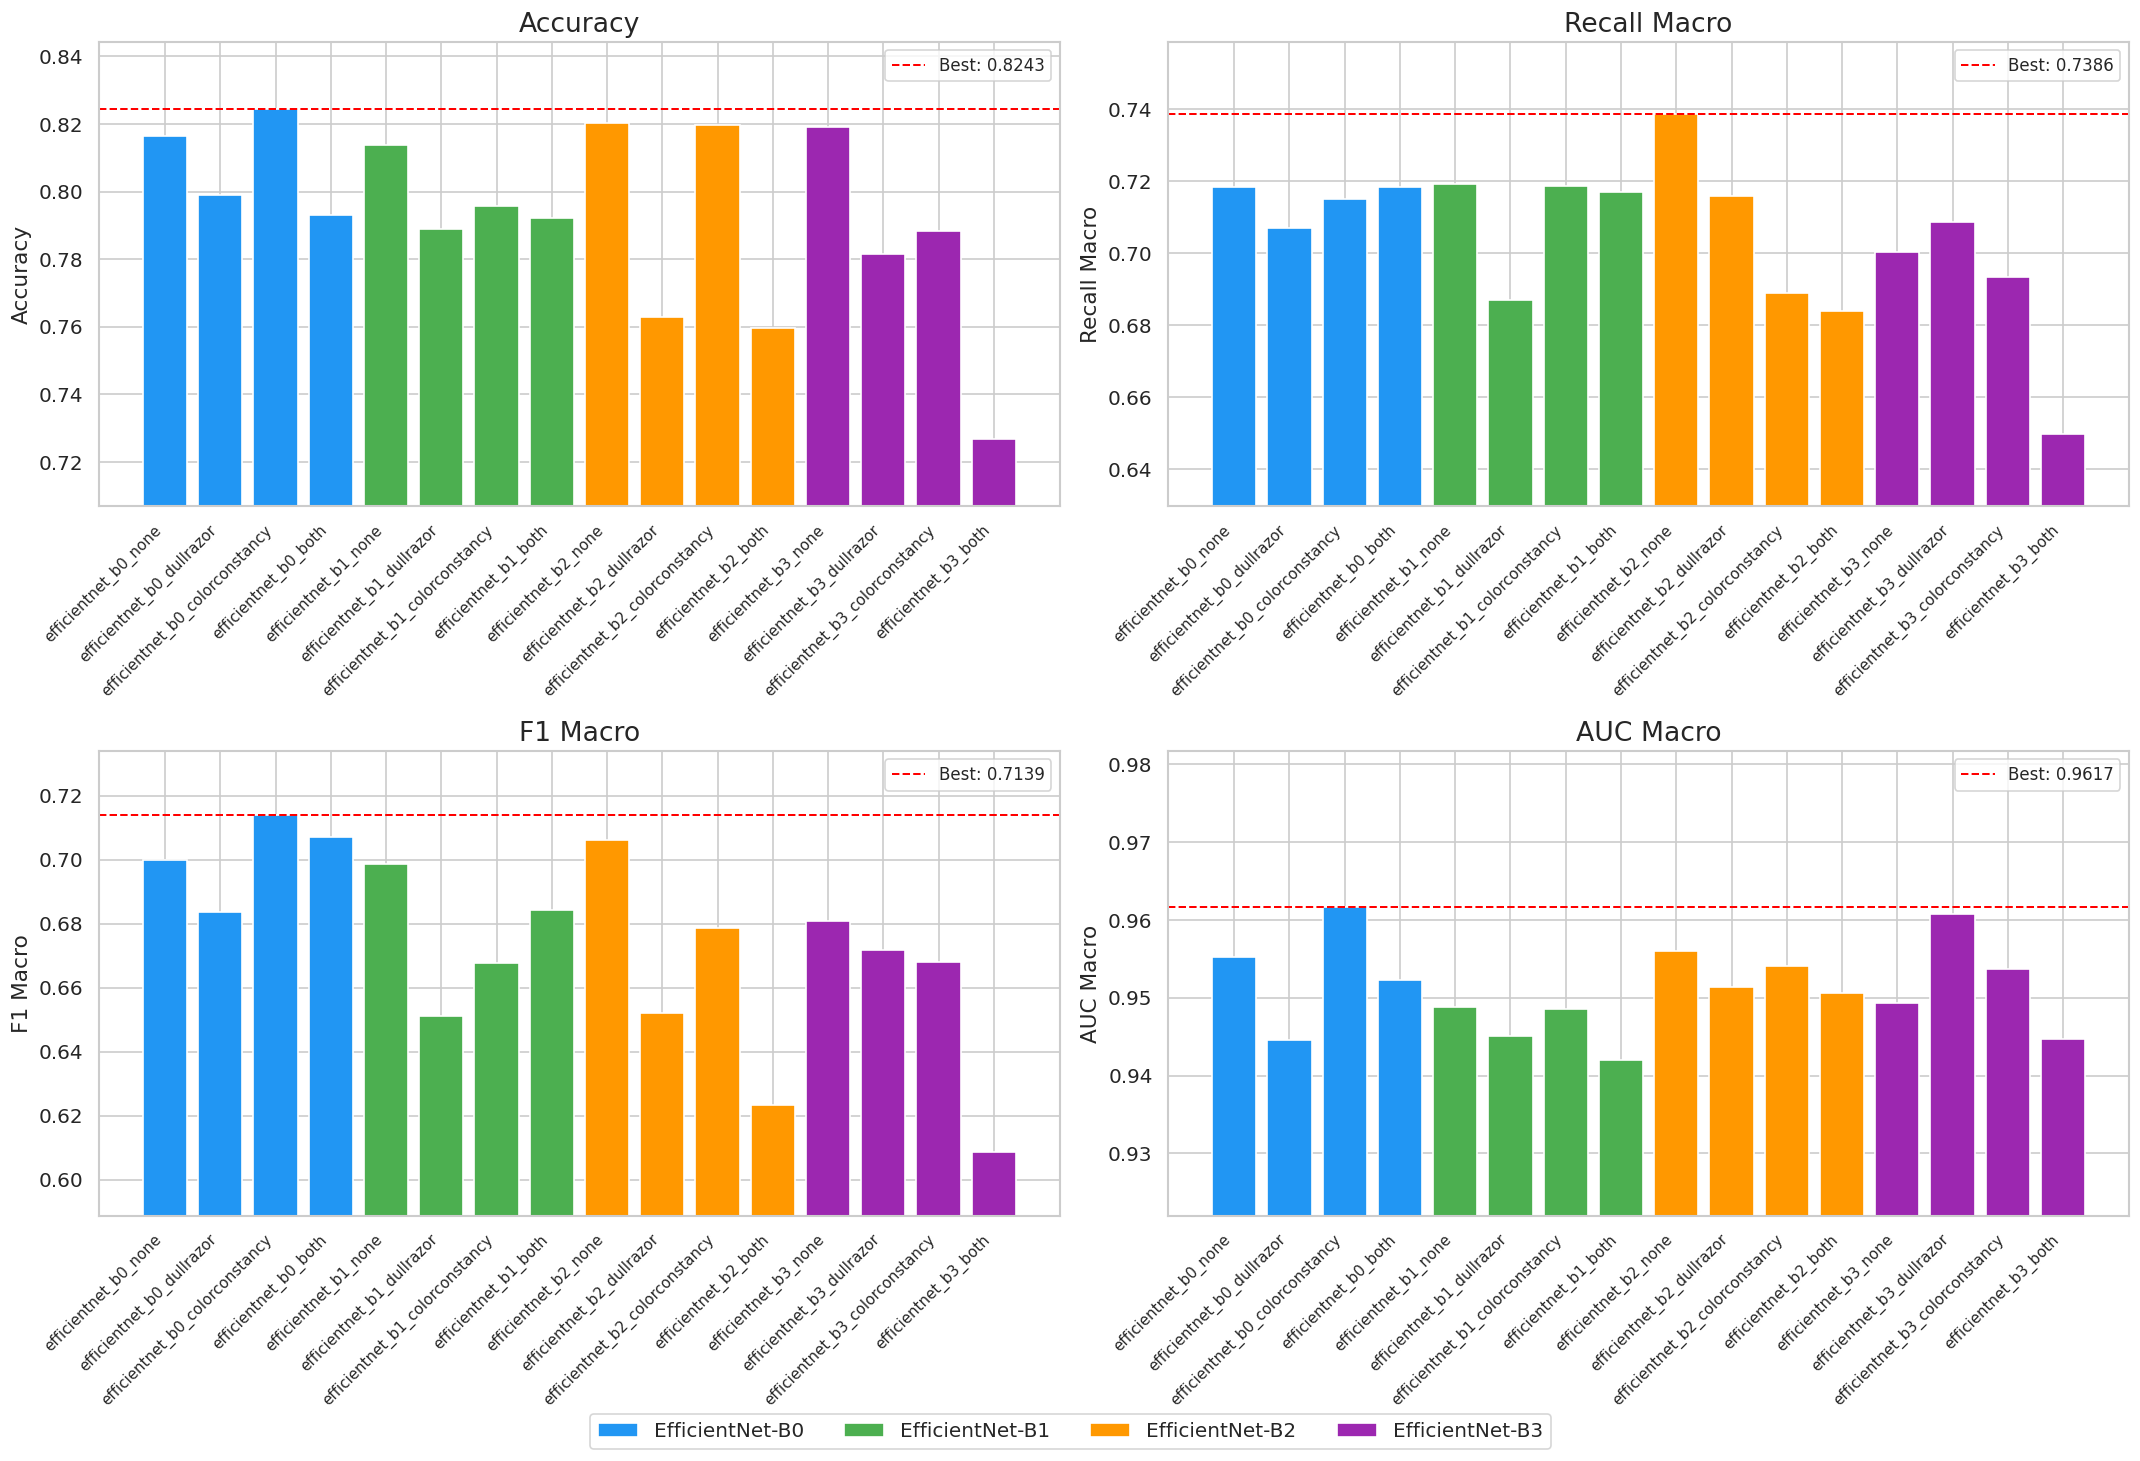

In [5]:
metrics    = ['accuracy', 'recall_macro', 'f1_macro', 'auc_macro']
metric_labels = ['Accuracy', 'Recall Macro', 'F1 Macro', 'AUC Macro']
colors_map = {'B0': '#2196F3', 'B1': '#4CAF50', 'B2': '#FF9800', 'B3': '#9C27B0'}

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

for ax, metric, label in zip(axes.flatten(), metrics, metric_labels):
    bar_colors = [colors_map[m] for m in test_df['model']]
    bars = ax.bar(test_df['experiment'], test_df[metric],
                  color=bar_colors, edgecolor='white')
    ax.set_title(label, fontsize=16)
    ax.set_ylabel(label, fontsize=13)
    ax.set_xticklabels(test_df['experiment'], rotation=45, ha='right', fontsize=9)
    ax.tick_params(axis='y', labelsize=12)
    ax.set_ylim(test_df[metric].min() - 0.02, test_df[metric].max() + 0.02)
    ax.axhline(test_df[metric].max(), color='red', linestyle='--',
               linewidth=1.2, label=f'Best: {test_df[metric].max():.4f}')
    ax.legend(fontsize=10)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'EfficientNet-{m}')
                   for m, c in colors_map.items()]
fig.legend(handles=legend_elements, fontsize=12, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'unimodal_global_metrics.png'),
            bbox_inches='tight', dpi=150)
plt.show()

### 3.2 Melanoma Recall & F1 — Clinical Priority

/tmp/ipykernel_271979/245381833.py:10: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[0].set_xticklabels(test_df['experiment'], rotation=45, ha='right', fontsize=9)
/tmp/ipykernel_271979/245381833.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  axes[1].set_xticklabels(test_df['experiment'], rotation=45, ha='right', fontsize=9)


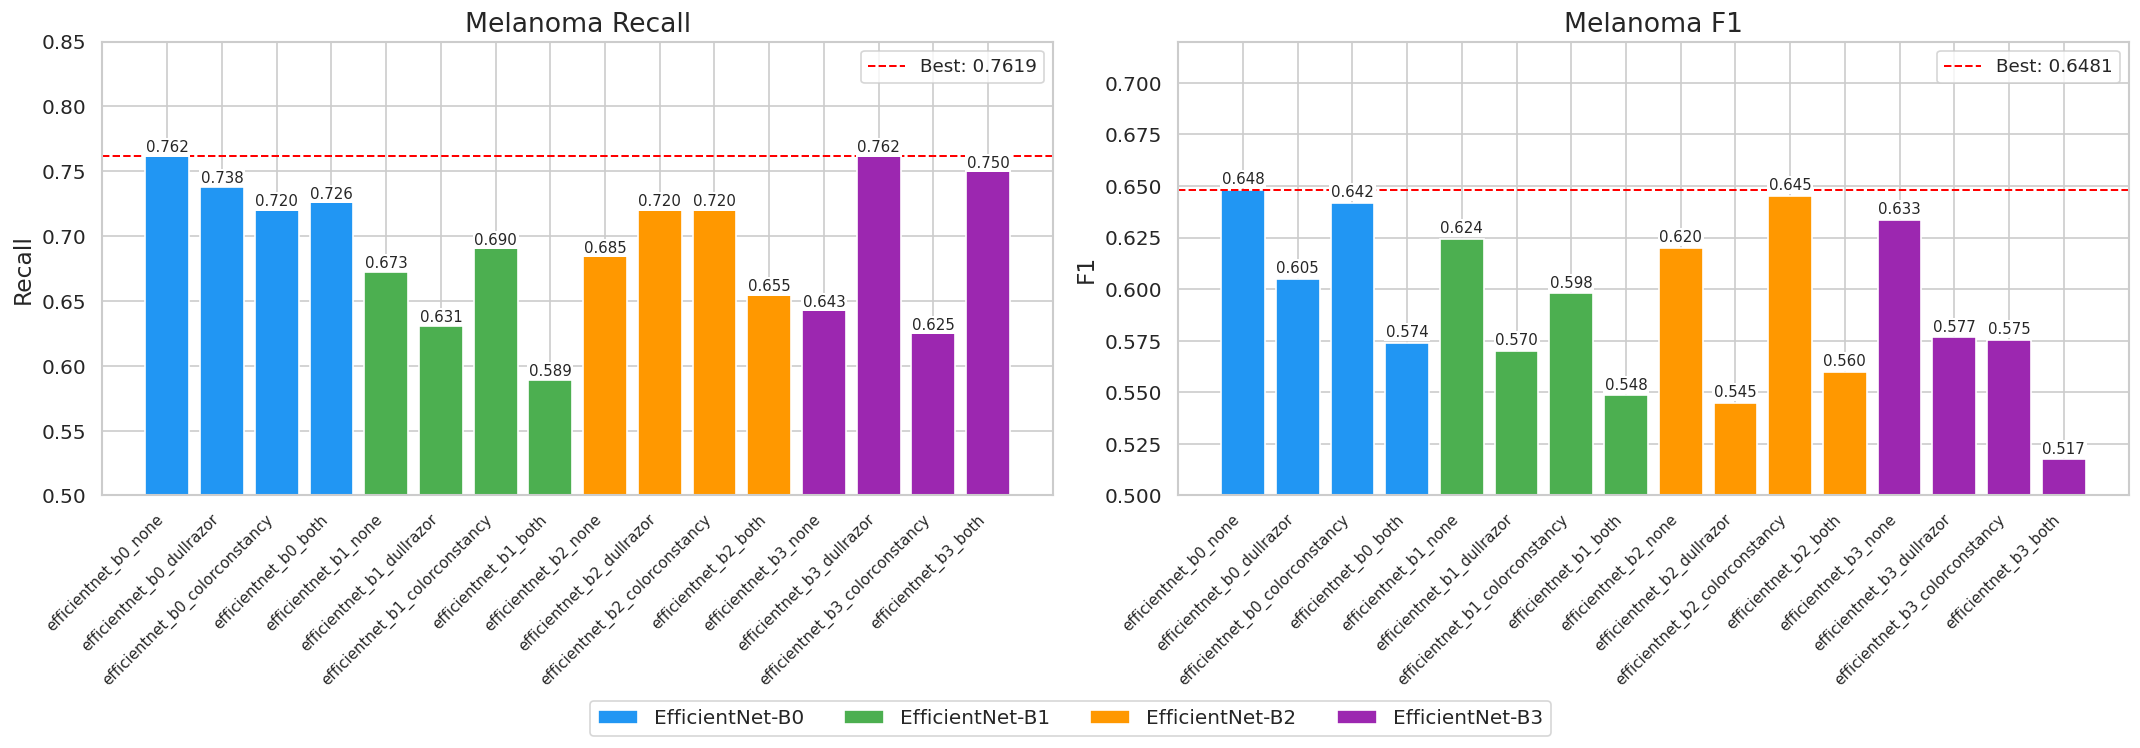

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
colors_map = {'B0': '#2196F3', 'B1': '#4CAF50', 'B2': '#FF9800', 'B3': '#9C27B0'}
bar_colors = [colors_map[m] for m in test_df['model']]

# Recall melanoma
bars = axes[0].bar(test_df['experiment'], test_df['recall_mel'],
                   color=bar_colors, edgecolor='white')
axes[0].set_title('Melanoma Recall', fontsize=16)
axes[0].set_ylabel('Recall', fontsize=14)
axes[0].set_xticklabels(test_df['experiment'], rotation=45, ha='right', fontsize=9)
axes[0].tick_params(axis='y', labelsize=12)
axes[0].set_ylim(0.5, 0.85)
axes[0].axhline(test_df['recall_mel'].max(), color='red', linestyle='--',
                linewidth=1.2, label=f'Best: {test_df["recall_mel"].max():.4f}')
for bar, val in zip(bars, test_df['recall_mel']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', fontsize=9,
                 bbox=dict(facecolor='white', edgecolor='none', pad=1))
axes[0].legend(fontsize=11)

# F1 melanoma
bars = axes[1].bar(test_df['experiment'], test_df['f1_mel'],
                   color=bar_colors, edgecolor='white')
axes[1].set_title('Melanoma F1', fontsize=16)
axes[1].set_ylabel('F1', fontsize=14)
axes[1].set_xticklabels(test_df['experiment'], rotation=45, ha='right', fontsize=9)
axes[1].tick_params(axis='y', labelsize=12)
axes[1].set_ylim(0.5, 0.72)
axes[1].axhline(test_df['f1_mel'].max(), color='red', linestyle='--',
                linewidth=1.2, label=f'Best: {test_df["f1_mel"].max():.4f}')
for bar, val in zip(bars, test_df['f1_mel']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                 f'{val:.3f}', ha='center', fontsize=9,
                 bbox=dict(facecolor='white', edgecolor='none', pad=1))
axes[1].legend(fontsize=11)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'EfficientNet-{m}')
                   for m, c in colors_map.items()]
fig.legend(handles=legend_elements, fontsize=12, loc='lower center',
           ncol=4, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'unimodal_melanoma_metrics.png'),
            bbox_inches='tight', dpi=150)
plt.show()

### 3.3 Per-class Recall Heatmap

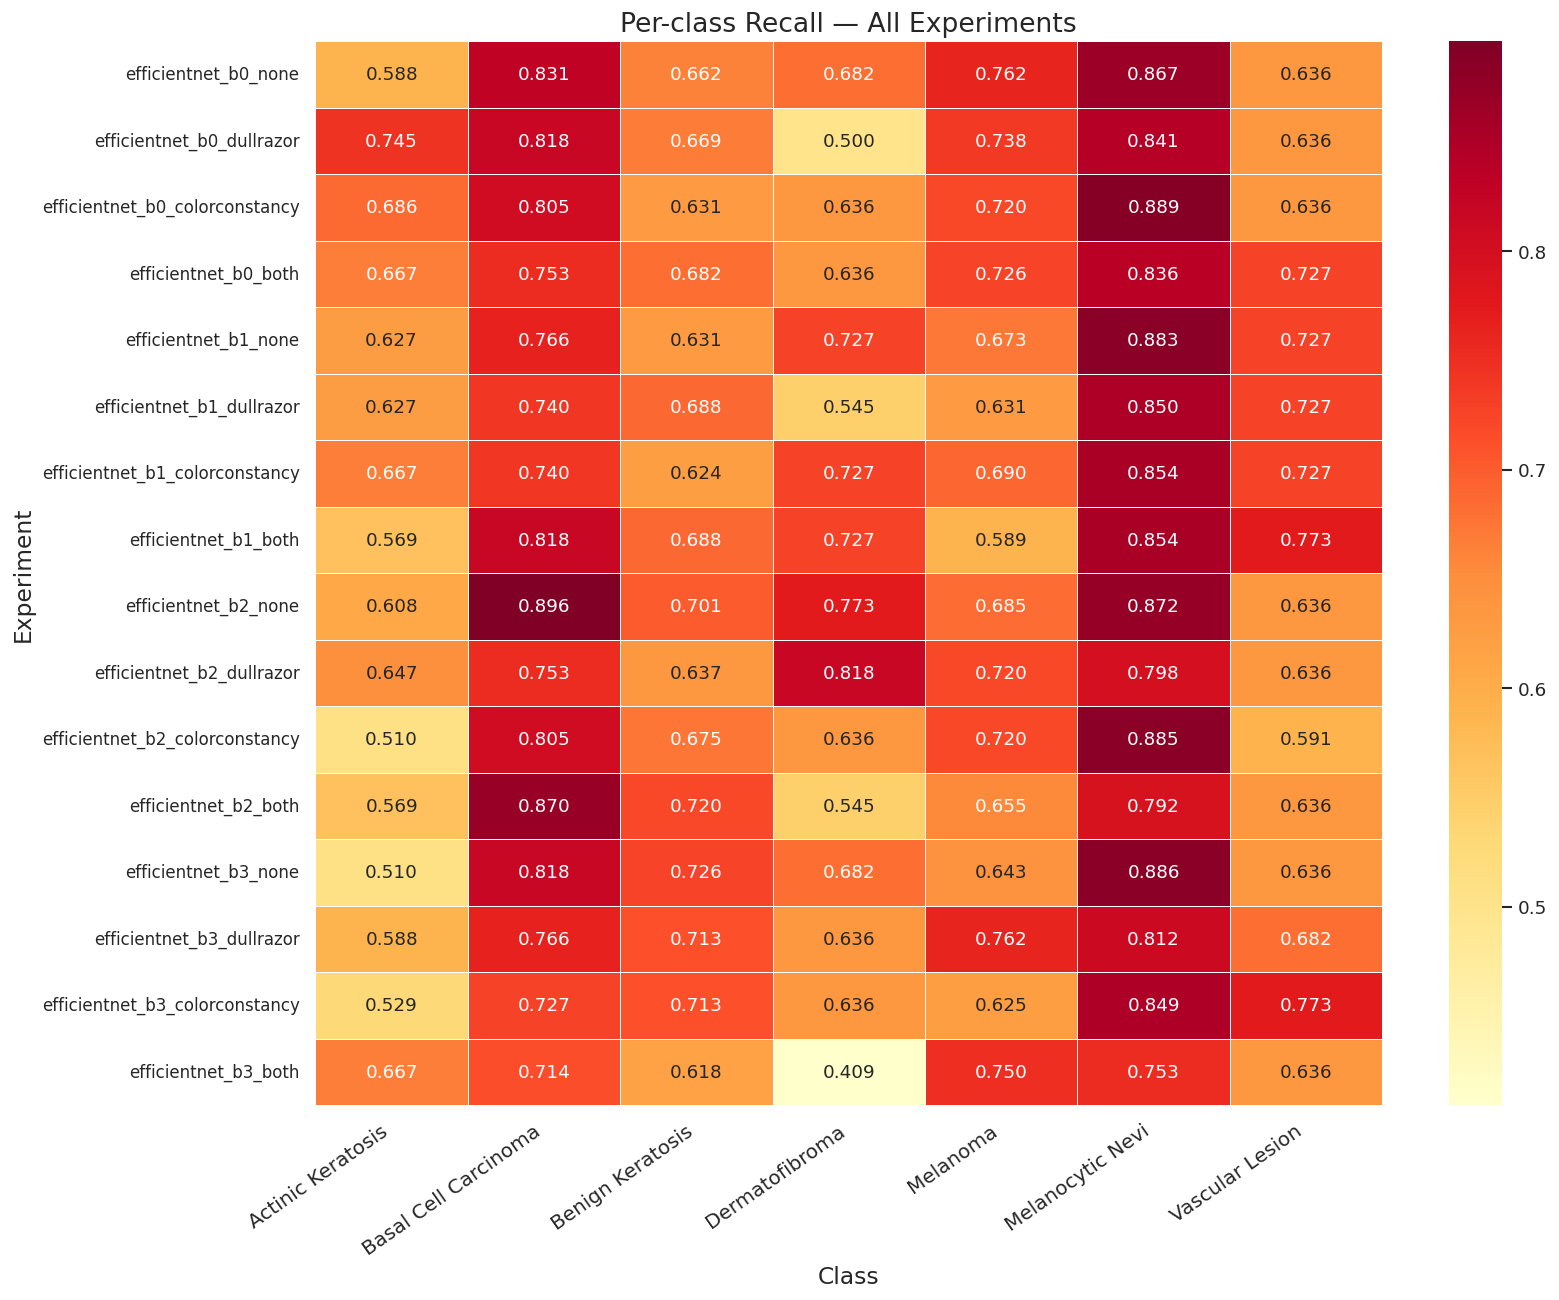

In [7]:
recall_cols = [f'recall_{c}' for c in CLASSES]
class_labels = [CLASS_NAMES_FULL[c] for c in CLASSES]

recall_matrix = test_df[recall_cols].values
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(
    recall_matrix,
    annot=True, fmt='.3f',
    cmap='YlOrRd',
    xticklabels=class_labels,
    yticklabels=test_df['experiment'],
    annot_kws={'size': 11},
    linewidths=0.5, linecolor='white',
    ax=ax
)
ax.set_title('Per-class Recall — All Experiments', fontsize=16)
ax.set_xlabel('Class', fontsize=14)
ax.set_ylabel('Experiment', fontsize=14)
ax.set_xticklabels(class_labels, rotation=35, ha='right', fontsize=12)
ax.tick_params(axis='y', labelsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'unimodal_perclass_recall_heatmap.png'),
            bbox_inches='tight', dpi=150)
plt.show()

### 3.4 Preprocessing Comparison per Backbone

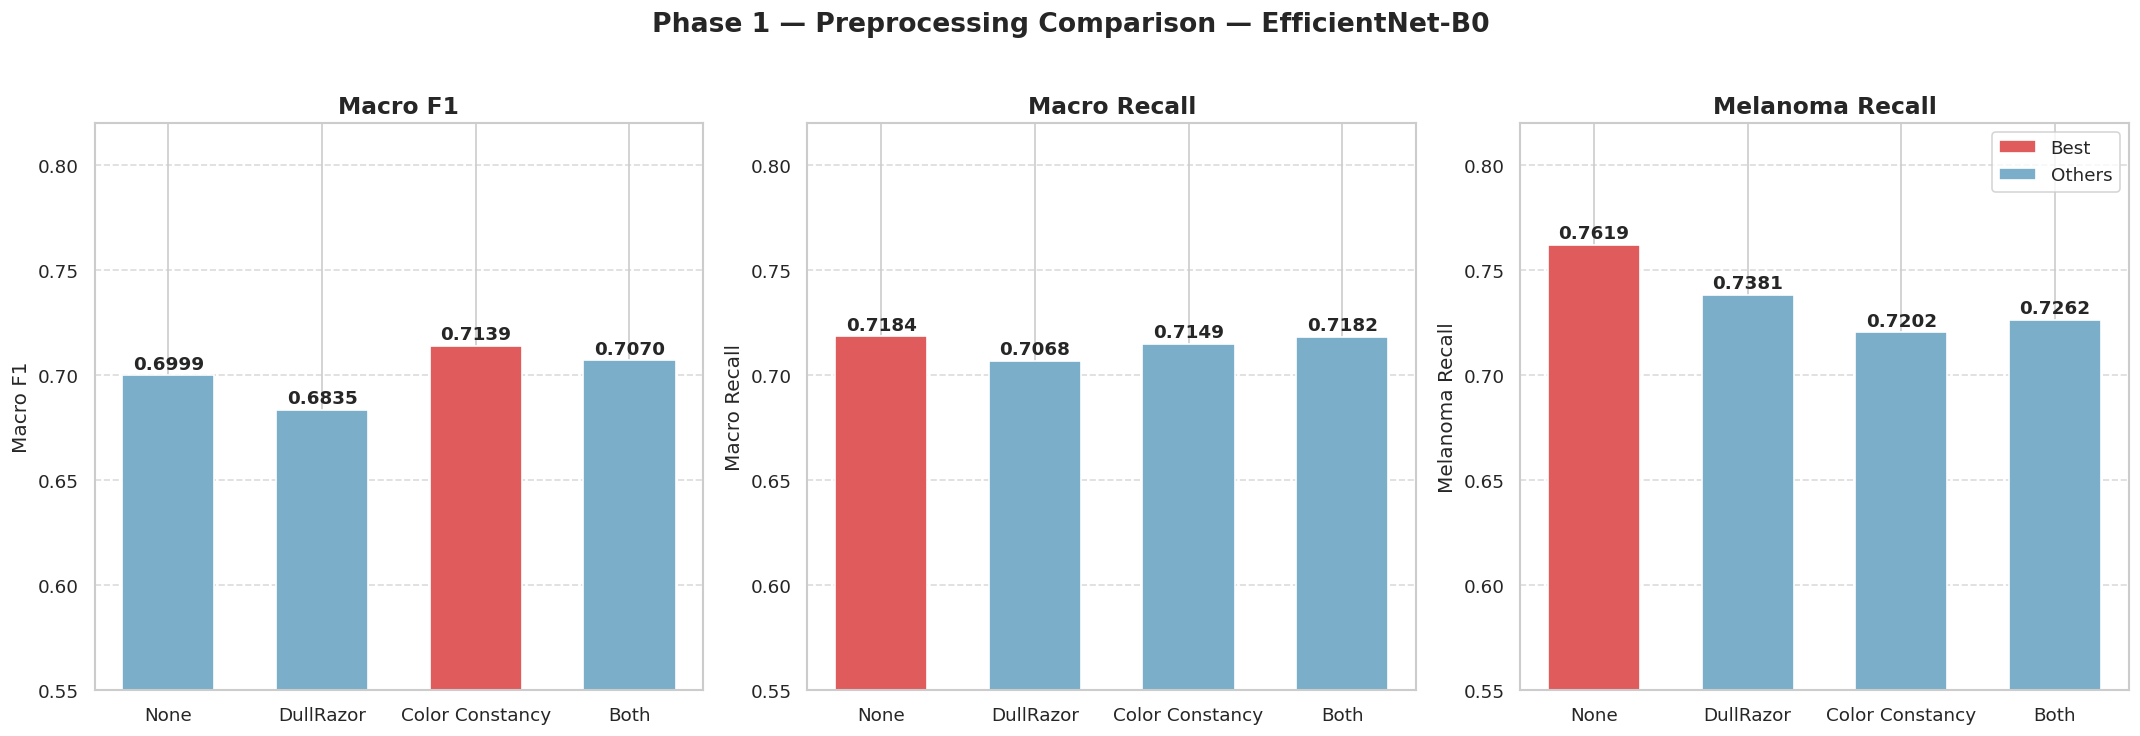

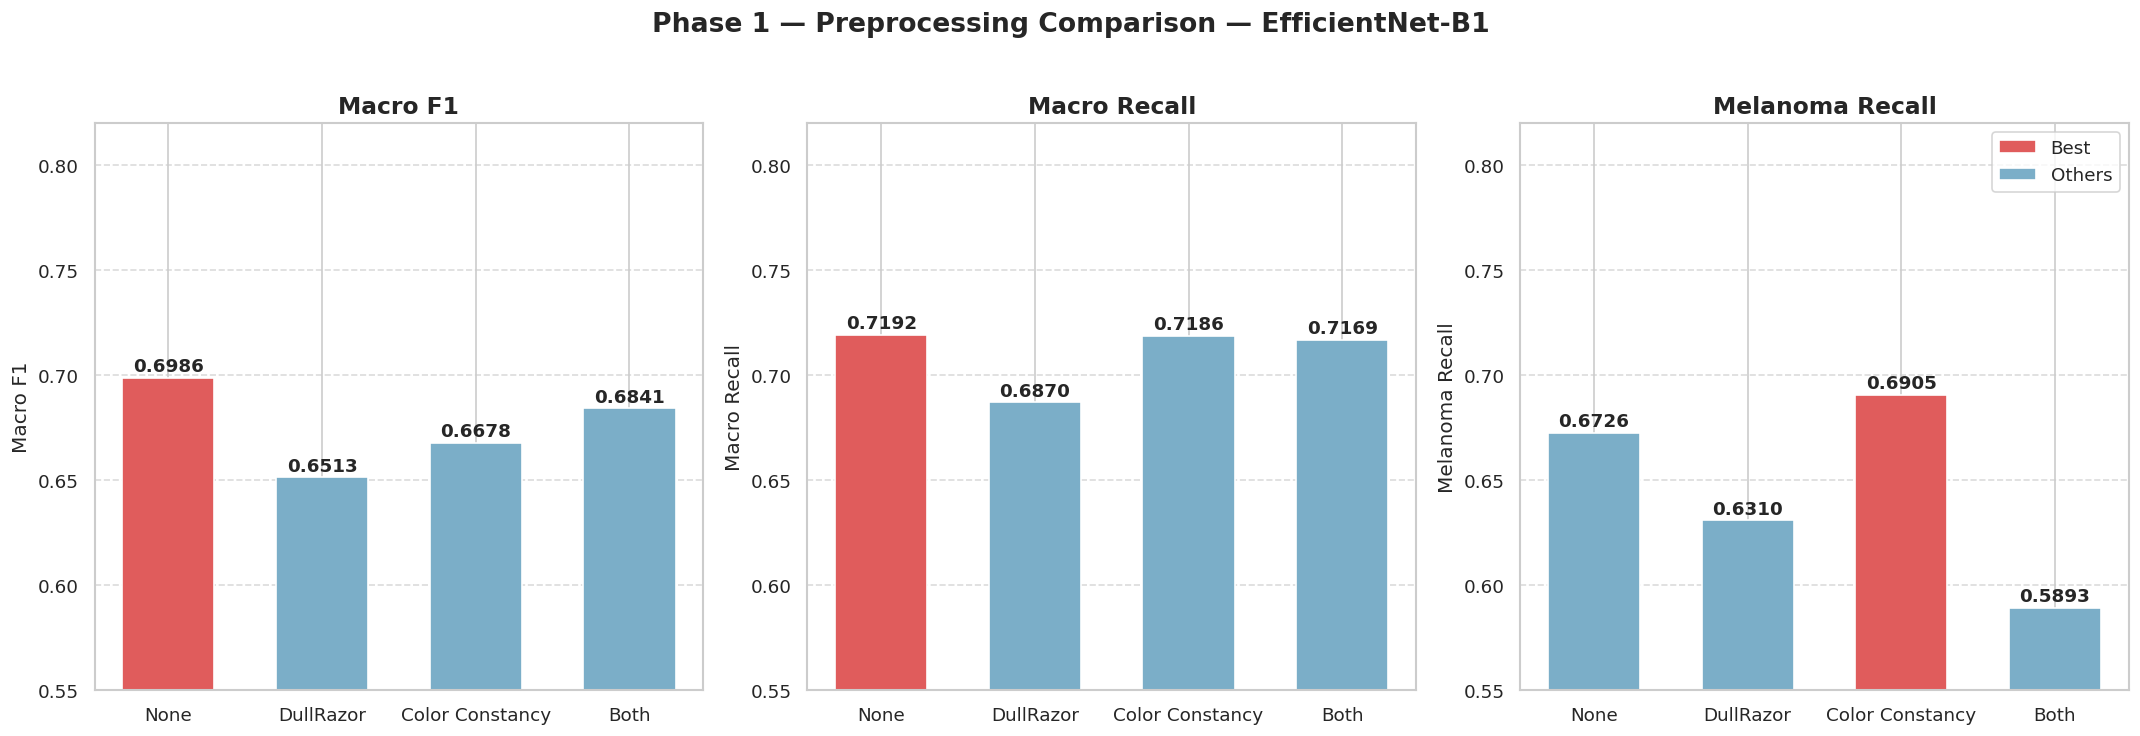

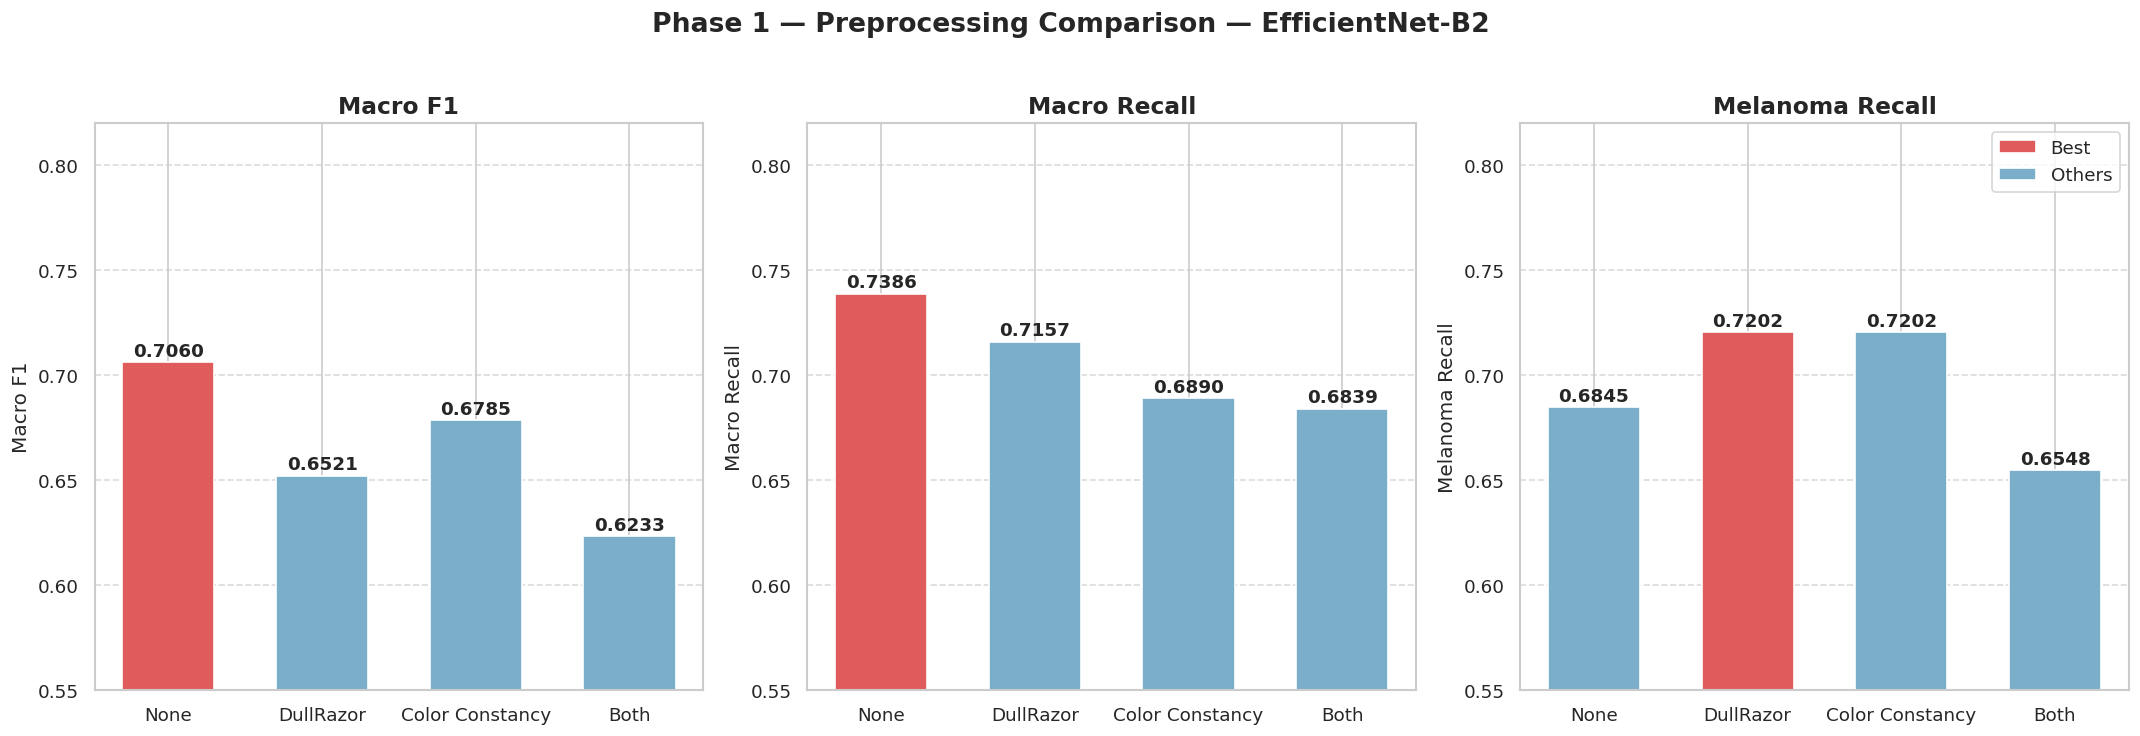

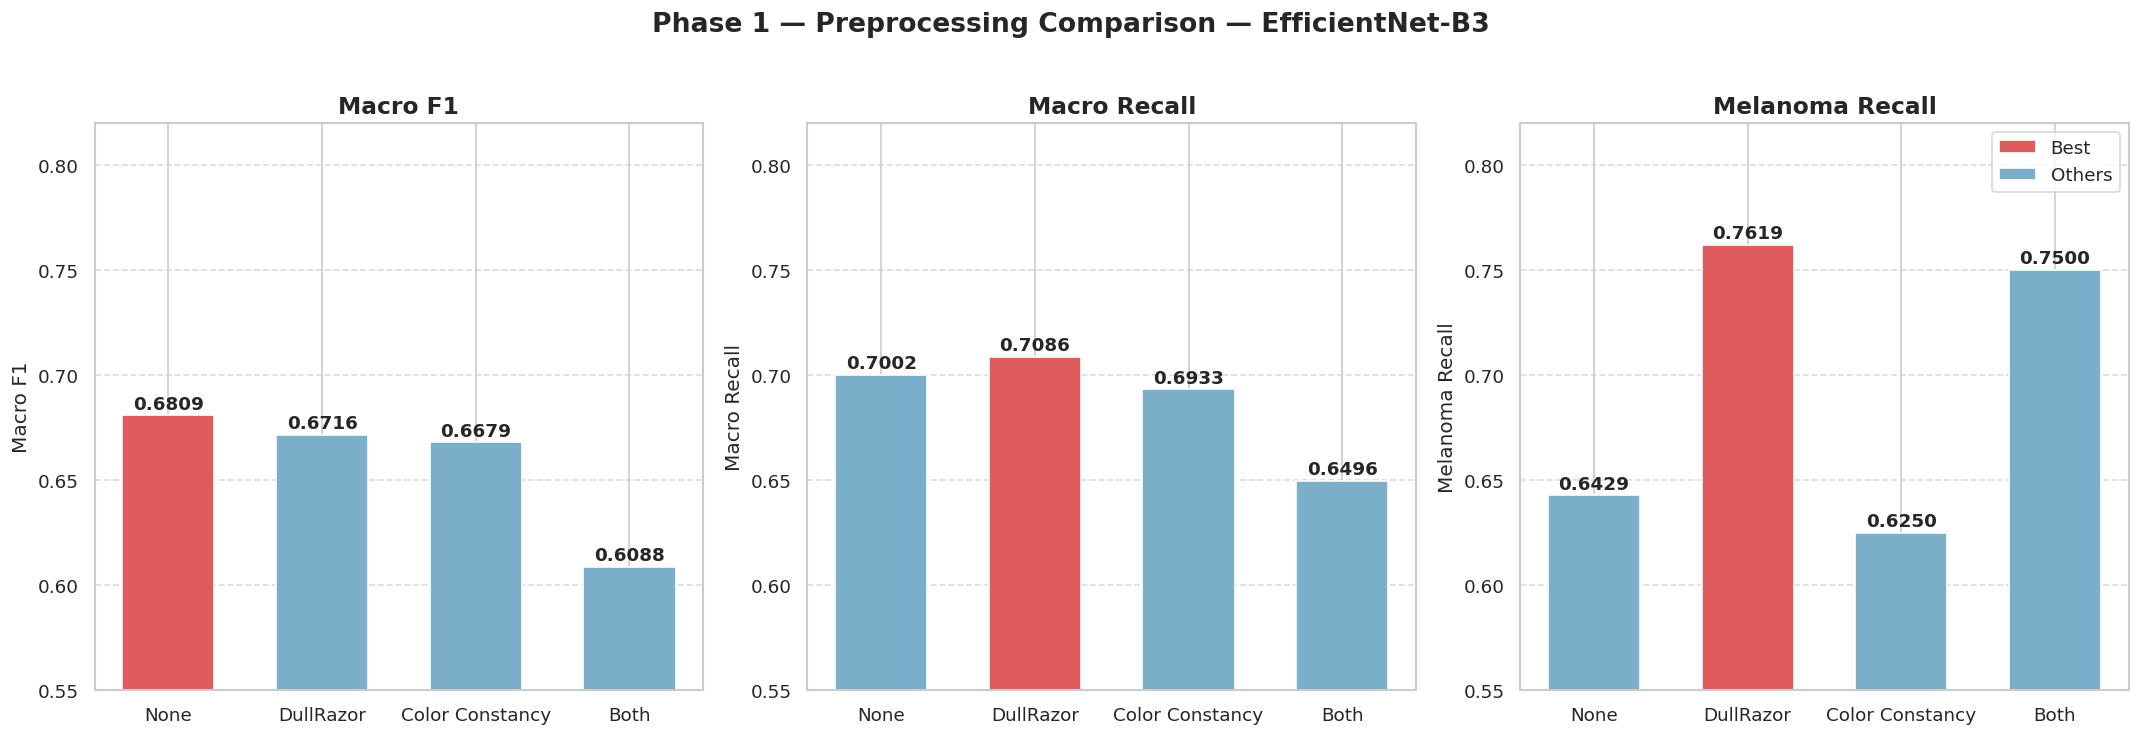

In [10]:
preprocess_labels = ['None', 'DullRazor', 'Color Constancy', 'Both']
preprocess_modes  = ['none', 'dullrazor', 'colorconstancy', 'both']
backbones         = ['b0', 'b1', 'b2', 'b3']
metrics_to_plot   = ['f1_macro', 'recall_macro', 'recall_mel']
metric_labels     = ['Macro F1', 'Macro Recall', 'Melanoma Recall']
ylims = [(0.55, 0.82), (0.55, 0.82), (0.55, 0.82)]

for backbone in backbones:
    mask  = test_df['model'] == backbone.upper()
    df_bb = test_df[mask].copy()
    df_bb = df_bb.set_index('preprocessing')
    df_bb = df_bb.reindex(['None', 'DullRazor', 'Color Constancy', 'Both'])

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'Phase 1 — Preprocessing Comparison — EfficientNet-{backbone.upper()}',
                 fontsize=16, fontweight='bold', y=1.02)

    for ax, metric, mlabel, ylim in zip(axes, metrics_to_plot, metric_labels, ylims):
        values    = df_bb[metric].values
        best_idx  = values.argmax()
        colors    = ['#E05C5C' if i == best_idx else '#7BAEC8'
                     for i in range(len(values))]

        bars = ax.bar(preprocess_labels, values, color=colors,
                      edgecolor='white', width=0.6)
        ax.set_title(mlabel, fontsize=14, fontweight='bold')
        ax.set_ylim(ylim)
        ax.set_ylabel(mlabel, fontsize=12)
        ax.tick_params(axis='both', labelsize=11)
        ax.yaxis.grid(True, linestyle='--', alpha=0.7)
        ax.set_axisbelow(True)

        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.003,
                    f'{val:.4f}', ha='center', fontsize=11,
                    fontweight='bold')

    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E05C5C', label='Best'),
        Patch(facecolor='#7BAEC8', label='Others')
    ]
    axes[-1].legend(handles=legend_elements, fontsize=11, loc='upper right')

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR,
                f'preprocessing_comparison_{backbone}.png'),
                bbox_inches='tight', dpi=150)
    plt.show()

1. AUC-ROC macro (la más importante)
No depende del umbral de clasificación y es robusta al desbalance. Mide la capacidad discriminativa del modelo entre clases independientemente de su frecuencia.
2. Recall macro
Más importante que accuracy en medicina. Un modelo que siempre predice "nv" tendría 67% de accuracy pero recall macro muy bajo. El recall macro penaliza ignorar las clases minoritarias.
3. Recall por clase minoritaria (especialmente melanoma)
Clínicamente es el más crítico. Un falso negativo en melanoma puede costar una vida. Por eso nos importa más el recall de mel que el F1 de mel.
4. F1 macro
Equilibrio entre precision y recall. Útil como métrica resumen pero menos informativa que el recall en contexto médico.

## 4. Overfitting Check — K-Fold Val AUC vs Test AUC

In [12]:
overfit_data = []

for version, preprocessing in [('b0','none'), ('b1','none'), ('b2','none'), ('b3','none')]:
    # K-Fold val AUC
    summary_path = os.path.join(METRICS_DIR, f'efficientnet_{version}_{preprocessing}_summary.csv')
    summary      = pd.read_csv(summary_path)
    val_auc      = summary['mean_auc'].values[0]

    # Test AUC
    test_path = os.path.join(METRICS_DIR, f'efficientnet_{version}_{preprocessing}_test_metrics.csv')
    test      = pd.read_csv(test_path)
    test_auc  = test['auc_macro'].values[0]

    gap = val_auc - test_auc
    overfit_data.append({
        'experiment':  f'efficientnet_{version}_{preprocessing}',
        'val_auc':     round(val_auc, 4),
        'test_auc':    round(test_auc, 4),
        'gap':         round(gap, 4),
        'overfitting': 'Possible Overfitting' if gap > 0.02 else 'OK'
    })

overfit_df = pd.DataFrame(overfit_data)
print(overfit_df.to_string(index=False))

          experiment  val_auc  test_auc    gap overfitting
efficientnet_b0_none   0.9593    0.9552 0.0041          OK
efficientnet_b1_none   0.9534    0.9489 0.0045          OK
efficientnet_b2_none   0.9570    0.9559 0.0010          OK
efficientnet_b3_none   0.9588    0.9494 0.0094          OK
